# 03 - Dataset Preparation and Quality Audit

> **Research question:** How can a supervised dataset teach reliable tool routing without leaking evaluation examples into training?

Notebook 02 showed that a structured system prompt could transform the raw model into a strong routing agent. However, the resulting behavior depended on a fixed 2,469-token prompt containing extensive routing rules.

This notebook documents the construction and validation of the supervised dataset used to transfer part of that routing policy into the model weights.

The analysis focuses on:

- dataset schema and formatting;
- train, validation and benchmark separation;
- tool and category coverage;
- response-type balance;
- multi-step plan validity;
- parameter diversity;
- duplicate and leakage detection;
- remaining dataset limitations.

Dataset statistics are transcribed from the raw outputs produced by the dataset
audit cells and stored in explicit Python dictionaries to keep every figure and
table reproducible from one canonical source.

## Executive Summary

The fine-tuning corpus is designed as a supervised routing dataset. Each example maps a natural-language request to one exact AXION response encoded as compact JSON.

Three data roles must remain distinct:

| Dataset | Purpose | Used for weight updates |
|---|---|---:|
| Training set | Learn routing behavior | Yes |
| Validation set | Select checkpoints and detect overfitting | No |
| Final benchmark | Compare system configurations | No |

The benchmark introduced in Notebook 01 is never used to update model weights or select individual training examples.

This notebook verifies that the training corpus:

1. follows the expected conversation schema;
2. contains only registered categories and tools;
3. provides sufficient coverage of routing behaviors;
4. respects AXION's execution constraints;
5. remains separate from the final evaluation benchmark.


The final audited corpus used for the `finetuning-v6` experiment contains no
known schema violation, no plan outside the declared two-to-five-step range and
no exact normalized overlap with the 320-prompt benchmark.

In [1]:
import hashlib
import json
import platform
import re
import sys
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path("..")

TRAIN_PATH = PROJECT_ROOT / "data" / "finetuning" / "train.jsonl"
VALID_PATH = PROJECT_ROOT / "data" / "finetuning" / "valid.jsonl"
BENCHMARK_PATH = PROJECT_ROOT / "data" / "test.jsonl"

DATA_PATHS = {
    "train": TRAIN_PATH,
    "validation": VALID_PATH,
    "benchmark": BENCHMARK_PATH,
}

for name, path in DATA_PATHS.items():
    print(f"{name:>10}: {path} — exists={path.exists()}")

     train: ../data/finetuning/train.jsonl — exists=True
validation: ../data/finetuning/valid.jsonl — exists=True
 benchmark: ../data/test.jsonl — exists=True


In [3]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    """Load a JSONL file and report malformed lines precisely."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")

    records: list[dict[str, Any]] = []

    with path.open("r", encoding="utf-8") as file:
        for line_number, raw_line in enumerate(file, start=1):
            line = raw_line.strip()

            if not line:
                continue

            try:
                record = json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON in {path} at line {line_number}: {error}"
                ) from error

            if not isinstance(record, dict):
                raise TypeError(
                    f"Expected a JSON object in {path} at line {line_number}"
                )

            records.append(record)

    return records


datasets = {}

for name, path in DATA_PATHS.items():
    if path.exists():
        datasets[name] = load_jsonl(path)
        print(f"{name:>10}: {len(datasets[name]):,} records")
    else:
        print(f"{name:>10}: unavailable")

     train: 2,294 records
validation: 300 records
 benchmark: 320 records


In [4]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(8192), b""):
            digest.update(chunk)

    return digest.hexdigest()


file_manifest = []

for name, path in DATA_PATHS.items():
    if not path.exists():
        continue

    file_manifest.append({
        "Dataset": name,
        "Path": str(path),
        "Examples": len(datasets[name]),
        "SHA-256": sha256_file(path),
    })

manifest_df = pd.DataFrame(file_manifest)

display(
    manifest_df.style
    .hide(axis="index")
)

Dataset,Path,Examples,SHA-256
train,../data/finetuning/train.jsonl,2294,c120b2c8246dbe877a9205124c83fd4c356ae82ab3fd0536d4cacf18af5ce0f8
validation,../data/finetuning/valid.jsonl,300,a571f4c07bb120d42865dfd1d3bd6e85987d4a2dfcb33b7af583bf637c4c07f8
benchmark,../data/test.jsonl,320,8be7359d6ad2fe846d4ccc0d6091cf1f6744319c23e362c3a39c5629eb5c07fc


In [5]:
DATASET_HASHES = {
    # Transcribed from the raw outputs produced by the dataset audit cells.
    "train": "c120b2c8246dbe877a9205124c83fd4c356ae82ab3fd0536d4cacf18af5ce0f8",
    "validation": "a571f4c07bb120d42865dfd1d3bd6e85987d4a2dfcb33b7af583bf637c4c07f8",
    "benchmark": "8be7359d6ad2fe846d4ccc0d6091cf1f6744319c23e362c3a39c5629eb5c07fc",
}

In [6]:
for dataset_name, expected_hash in DATASET_HASHES.items():
    actual_hash = sha256_file(DATA_PATHS[dataset_name])

    assert actual_hash == expected_hash, (
        f"Hash mismatch for {dataset_name}: "
        f"{actual_hash} != {expected_hash}"
    )

print("All dataset hashes match the canonical cleaned corpus.")

All dataset hashes match the canonical cleaned corpus.


## Canonical Audited Results

The values below were transcribed from the raw outputs produced by the dataset
audit cells after the corpus was cleaned for the `finetuning-v6` experiment.

The canonical dictionary is the single source of truth for the descriptive
tables and captions in this notebook. The live audit cells remain present to
verify that the current files reproduce these results.

In [7]:
DATASET_AUDIT = {
    "version": "finetuning-v6-clean",
    "training_examples": 2294,
    "validation_examples": 300,
    "benchmark_examples": 320,
    "supervised_examples": 2594,
    "registered_tools": 37,
    "schema_errors": 0,
    "invalid_plan_lengths": 0,
    "train_validation_overlap": 0,
    "train_benchmark_overlap": 0,
    "validation_benchmark_overlap": 0,
    "benchmark_exposure_rate_percent": 0.0,
    "normalized_duplicate_prompt_groups": 2,
    "conflicting_normalized_prompts": 0,
    "duplicate_completion_rows": 1122,
}

DATASET_AUDIT


{'version': 'finetuning-v6-clean',
 'training_examples': 2294,
 'validation_examples': 300,
 'benchmark_examples': 320,
 'supervised_examples': 2594,
 'registered_tools': 37,
 'schema_errors': 0,
 'invalid_plan_lengths': 0,
 'train_validation_overlap': 0,
 'train_benchmark_overlap': 0,
 'validation_benchmark_overlap': 0,
 'benchmark_exposure_rate_percent': 0.0,
 'normalized_duplicate_prompt_groups': 2,
 'conflicting_normalized_prompts': 0,
 'duplicate_completion_rows': 1122}

In [8]:
assert len(datasets["train"]) == DATASET_AUDIT["training_examples"]
assert len(datasets["validation"]) == DATASET_AUDIT["validation_examples"]
assert len(datasets["benchmark"]) == DATASET_AUDIT["benchmark_examples"]

print("Canonical counts match the current JSONL files.")

Canonical counts match the current JSONL files.


In [9]:
def summarize_record(record: dict[str, Any]) -> dict[str, Any]:
    summary = {}

    for key, value in record.items():
        if isinstance(value, str):
            summary[key] = value[:200] + ("..." if len(value) > 200 else "")
        elif isinstance(value, list):
            summary[key] = f"list[{len(value)}]"
        elif isinstance(value, dict):
            summary[key] = f"dict[{len(value)}]"
        else:
            summary[key] = value

    return summary


if "train" in datasets and datasets["train"]:
    print("Top-level keys:", list(datasets["train"][0].keys()))
    display(pd.DataFrame([summarize_record(datasets["train"][0])]))

Top-level keys: ['prompt', 'completion']


,prompt,completion
0,send notification Build Ready for QA,"{""type"":""tool_call"",""category"":""system"",""tool""..."


In [10]:
TOOL_REGISTRY = {
    "files": {
        "open_file",
        "reveal_file",
        "read_text_file",
        "create_text_file",
        "append_text_file",
        "list_directory",
        "create_folder",
        "get_file_info",
        "rename_file",
        "move_file",
        "delete_file",
        "search_file_content",
        "read_pdf_text",
        "compress_file",
        "extract_archive",
        "organize_folder",
        "clean_folder",
    },
    "web_apps": {
        "open_app",
        "open_url",
        "quit_app",
        "focus_app",
        "hide_app",
    },
    "text": {
        "copy_to_clipboard",
        "get_clipboard",
        "get_current_datetime",
        "search_in_spotlight",
    },
    "system": {
        "show_notification",
        "take_screenshot",
        "set_volume",
        "get_battery_status",
        "toggle_dark_mode",
    },
    "dev": {
        "list_processes",
        "open_in_vscode",
        "git_status",
        "open_terminal_here",
    },
    "third_party": {
        "create_reminder",
        "create_calendar_event",
    },
}

ALL_TOOLS = {
    tool
    for tools in TOOL_REGISTRY.values()
    for tool in tools
}

print("Categories:", len(TOOL_REGISTRY))
print("Registered tools:", len(ALL_TOOLS))

Categories: 6
Registered tools: 37


In [11]:
def parse_completion(record: dict[str, Any]) -> dict[str, Any]:
    """Parse the JSON response stored in a dataset record."""
    completion = record.get("completion")

    if not isinstance(completion, str):
        raise TypeError("completion must be a string")

    parsed = json.loads(completion)

    if not isinstance(parsed, dict):
        raise TypeError("completion JSON must contain an object")

    return parsed

In [12]:
ALLOWED_RESPONSE_TYPES = {
    "tool_call",
    "plan",
    "final",
}


def validate_action(
    action: dict[str, Any],
    *,
    location: str,
) -> list[str]:
    """Validate one executable AXION action."""
    errors: list[str] = []

    if not isinstance(action, dict):
        return [f"{location}: action must be an object"]

    expected_keys = {"category", "tool", "params"}
    actual_keys = set(action)

    missing = expected_keys - actual_keys
    extra = actual_keys - expected_keys

    if missing:
        errors.append(
            f"{location}: missing keys {sorted(missing)}"
        )

    if extra:
        errors.append(
            f"{location}: unexpected keys {sorted(extra)}"
        )

    category = action.get("category")
    tool = action.get("tool")
    params = action.get("params")

    if category not in TOOL_REGISTRY:
        errors.append(
            f"{location}: unknown category {category!r}"
        )
    elif tool not in TOOL_REGISTRY[category]:
        errors.append(
            f"{location}: tool {tool!r} does not belong "
            f"to category {category!r}"
        )

    if not isinstance(params, dict):
        errors.append(
            f"{location}: params must be an object"
        )

    return errors


def validate_record(
    record: dict[str, Any],
    *,
    dataset_name: str,
    index: int,
) -> list[str]:
    """Validate one prompt/completion record."""
    location = f"{dataset_name}[{index}]"
    errors: list[str] = []

    expected_record_keys = {"prompt", "completion"}

    if set(record) != expected_record_keys:
        errors.append(
            f"{location}: expected top-level keys "
            f"{sorted(expected_record_keys)}, got {sorted(record)}"
        )

    prompt = record.get("prompt")
    completion = record.get("completion")

    if not isinstance(prompt, str) or not prompt.strip():
        errors.append(
            f"{location}: prompt must be a non-empty string"
        )

    if not isinstance(completion, str) or not completion.strip():
        errors.append(
            f"{location}: completion must be a non-empty string"
        )
        return errors

    try:
        parsed = json.loads(completion)
    except json.JSONDecodeError as error:
        errors.append(
            f"{location}: malformed completion JSON: {error}"
        )
        return errors

    if not isinstance(parsed, dict):
        errors.append(
            f"{location}: completion must decode to an object"
        )
        return errors

    response_type = parsed.get("type")

    if response_type not in ALLOWED_RESPONSE_TYPES:
        errors.append(
            f"{location}: invalid response type {response_type!r}"
        )
        return errors

    if response_type == "tool_call":
        expected_keys = {"type", "category", "tool", "params"}

        if set(parsed) != expected_keys:
            errors.append(
                f"{location}: invalid tool_call keys {sorted(parsed)}"
            )

        errors.extend(
            validate_action(
                {
                    "category": parsed.get("category"),
                    "tool": parsed.get("tool"),
                    "params": parsed.get("params"),
                },
                location=location,
            )
        )

    elif response_type == "plan":
        expected_keys = {"type", "steps"}

        if set(parsed) != expected_keys:
            errors.append(
                f"{location}: invalid plan keys {sorted(parsed)}"
            )

        steps = parsed.get("steps")

        if not isinstance(steps, list):
            errors.append(
                f"{location}: plan steps must be a list"
            )
        else:
            if not 2 <= len(steps) <= 5:
                errors.append(
                    f"{location}: plan must contain 2 to 5 steps, "
                    f"got {len(steps)}"
                )

            # Validate every step even when the plan length itself is invalid.
            for step_index, step in enumerate(steps):
                errors.extend(
                    validate_action(
                        step,
                        location=f"{location}.steps[{step_index}]",
                    )
                )

    elif response_type == "final":
        expected_keys = {"type", "content"}

        if set(parsed) != expected_keys:
            errors.append(
                f"{location}: invalid final keys {sorted(parsed)}"
            )

        if parsed.get("content") != "OK":
            errors.append(
                f"{location}: final content must be 'OK'"
            )

    return errors


In [13]:
validation_rows = []

for dataset_name in ("train", "validation"):
    for index, record in enumerate(datasets[dataset_name]):
        record_errors = validate_record(
            record,
            dataset_name=dataset_name,
            index=index,
        )

        for error in record_errors:
            validation_rows.append({
                "dataset": dataset_name,
                "index": index,
                "error": error,
            })

validation_errors_df = pd.DataFrame(
    validation_rows,
    columns=["dataset", "index", "error"],
)

validated_examples = (
    len(datasets["train"])
    + len(datasets["validation"])
)

print(f"Validated examples: {validated_examples:,}")
print(f"Schema errors: {len(validation_errors_df):,}")

if validation_errors_df.empty:
    print("All fine-tuning records follow the expected schema.")
else:
    display(
        validation_errors_df.rename(
            columns={"error": "Error"}
        )[["Error"]]
    )

assert (
    len(validation_errors_df)
    == DATASET_AUDIT["schema_errors"]
)

print(
    "Schema result matches the canonical audited output:",
    DATASET_AUDIT["schema_errors"],
)


Validated examples: 2,594
Schema errors: 0
All fine-tuning records follow the expected schema.
Schema result matches the canonical audited output: 0


## Dataset Splits

The supervised corpus is divided into training and validation data.

The independent routing benchmark remains outside the fine-tuning corpus and is
used only for final model evaluation.

In [14]:
split_sizes = pd.DataFrame({
    "Split": [
        "Training",
        "Validation",
    ],
    "Examples": [
        DATASET_AUDIT["training_examples"],
        DATASET_AUDIT["validation_examples"],
    ],
})

split_sizes["Share (%)"] = (
    split_sizes["Examples"]
    / split_sizes["Examples"].sum()
    * 100
)

display(
    split_sizes.style
    .format({
        "Examples": "{:,.0f}",
        "Share (%)": "{:.1f}%",
    })
    .hide(axis="index")
)

Split,Examples,Share (%)
Training,"2,294",88.4%
Validation,300,11.6%


The cleaned supervised corpus contains **2,594 examples**:

- 2,294 training examples;
- 300 validation examples.

This corresponds to an approximately **88.4% / 11.6%** split.

The independent 320-example benchmark remains separate and is not included in
the supervised-example count.

These values were transcribed from the raw outputs produced by the dataset
audit cells for the corpus used by `finetuning-v6`.

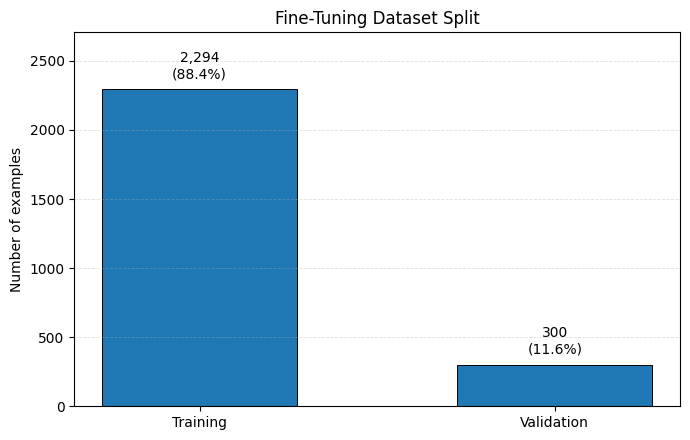

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    split_sizes["Split"],
    split_sizes["Examples"],
    width=0.55,
    edgecolor="black",
    linewidth=0.7,
)

for bar, share in zip(
    bars,
    split_sizes["Share (%)"],
):
    value = bar.get_height()

    ax.annotate(
        f"{value:,.0f}\n({share:.1f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            value,
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

ax.set_ylabel("Number of examples")
ax.set_title("Fine-Tuning Dataset Split")
ax.set_ylim(
    0,
    split_sizes["Examples"].max() * 1.18,
)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

**Figure 1 — Fine-tuning dataset split.** The cleaned supervised corpus contains
2,294 training examples and 300 validation examples, corresponding to an
approximately 88.4% / 11.6% split. The independent 320-example benchmark is
excluded.

In [16]:
def extract_actions(
    parsed_completion: dict[str, Any],
) -> list[dict[str, Any]]:
    """Return every executable action from a completion."""
    response_type = parsed_completion["type"]

    if response_type == "tool_call":
        return [{
            "category": parsed_completion["category"],
            "tool": parsed_completion["tool"],
            "params": parsed_completion["params"],
        }]

    if response_type == "plan":
        return parsed_completion["steps"]

    return []

In [17]:
example_rows = []
action_rows = []

for dataset_name in ("train", "validation"):
    for index, record in enumerate(datasets[dataset_name]):
        parsed = parse_completion(record)
        actions = extract_actions(parsed)

        example_rows.append({
            "dataset": dataset_name,
            "index": index,
            "prompt": record["prompt"],
            "completion": record["completion"],
            "response_type": parsed["type"],
            "step_count": len(actions),
            "parameter_count": sum(
                len(action["params"])
                for action in actions
            ),
            "categories": [
                action["category"]
                for action in actions
            ],
            "tools": [
                action["tool"]
                for action in actions
            ],
        })

        for step_position, action in enumerate(
            actions,
            start=1,
        ):
            action_rows.append({
                "dataset": dataset_name,
                "example_index": index,
                "response_type": parsed["type"],
                "step_position": step_position,
                "category": action["category"],
                "tool": action["tool"],
                "params": action["params"],
                "parameter_count": len(action["params"]),
            })

examples_df = pd.DataFrame(example_rows)
actions_df = pd.DataFrame(action_rows)

print(f"Examples: {len(examples_df):,}")
print(f"Executable actions: {len(actions_df):,}")

display(examples_df.head())

Examples: 2,594
Executable actions: 3,200


,dataset,index,prompt,completion,response_type,step_count,parameter_count,categories,tools
0,train,0,send notification Build Ready for QA,"{""type"":""tool_call"",""category"":""system"",""tool""...",tool_call,1,2,[system],[show_notification]
1,train,1,"take a screenshot to ~/Downloads/bug.png, reve...","{""type"":""plan"",""steps"":[{""category"":""system"",""...",plan,4,5,"[system, files, text, system]","[take_screenshot, reveal_file, copy_to_clipboa..."
2,train,2,"apply cleanup on ~/Projects/axion-scratch, arc...","{""type"":""plan"",""steps"":[{""category"":""files"",""t...",plan,4,7,"[files, files, files, system]","[clean_folder, compress_file, reveal_file, sho..."
3,train,3,open ~/Documents/spec.pdf,"{""type"":""tool_call"",""category"":""files"",""tool"":...",tool_call,1,1,[files],[open_file]
4,train,4,create reminder prepare budget sheet next wedn...,"{""type"":""tool_call"",""category"":""third_party"",""...",tool_call,1,2,[third_party],[create_reminder]


## Response-Type Distribution

Each completion uses one of three response modes:

- `tool_call`: one executable action;
- `plan`: multiple independent actions;
- `final`: terminal response after completion.

The balance between these modes determines whether the model primarily learns
single-step routing, multi-action planning or loop termination.

In [18]:
response_distribution = (
    examples_df
    .groupby(["dataset", "response_type"])
    .size()
    .rename("Examples")
    .reset_index()
)

response_distribution["Share (%)"] = (
    response_distribution["Examples"]
    / response_distribution
        .groupby("dataset")["Examples"]
        .transform("sum")
    * 100
)

display(
    response_distribution.style
    .format({
        "Examples": "{:,.0f}",
        "Share (%)": "{:.1f}%",
    })
    .hide(axis="index")
)

dataset,response_type,Examples,Share (%)
train,final,201,8.8%
train,plan,276,12.0%
train,tool_call,"1,817",79.2%
validation,final,20,6.7%
validation,plan,60,20.0%
validation,tool_call,220,73.3%


In [19]:
RESPONSE_TYPE_RESULTS = {
    # Transcribed from the raw outputs produced by the dataset audit cells.
    "train": {
        "final": {
            "examples": 201,
            "share_percent": 8.8,
        },
        "plan": {
            "examples": 276,
            "share_percent": 12.0,
        },
        "tool_call": {
            "examples": 1817,
            "share_percent": 79.2,
        },
    },
    "validation": {
        "final": {
            "examples": 20,
            "share_percent": 6.7,
        },
        "plan": {
            "examples": 60,
            "share_percent": 20.0,
        },
        "tool_call": {
            "examples": 220,
            "share_percent": 73.3,
        },
    },
}

computed_response_type_results = {
    dataset_name: {
        row["response_type"]: {
            "examples": int(row["Examples"]),
            "share_percent": round(
                float(row["Share (%)"]),
                1,
            ),
        }
        for _, row in response_distribution[
            response_distribution["dataset"] == dataset_name
        ].iterrows()
    }
    for dataset_name in ("train", "validation")
}

assert computed_response_type_results == RESPONSE_TYPE_RESULTS, (
    "Response-type distribution no longer matches "
    "the canonical audited results."
)

print(
    "Response-type distribution matches "
    "the canonical audited output."
)


Response-type distribution matches the canonical audited output.


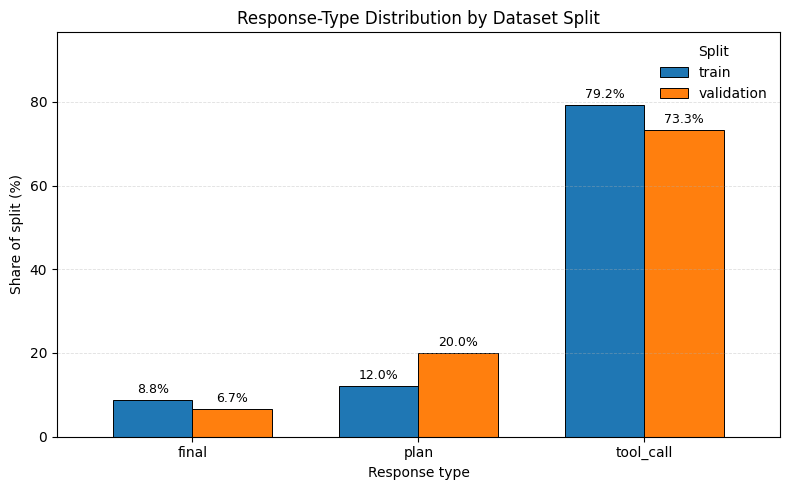

In [20]:
response_plot = (
    response_distribution
    .pivot(
        index="response_type",
        columns="dataset",
        values="Share (%)",
    )
    .fillna(0)
)

ax = response_plot.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.7,
    edgecolor="black",
    linewidth=0.7,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9,
    )

ax.set_xlabel("Response type")
ax.set_ylabel("Share of split (%)")
ax.set_title("Response-Type Distribution by Dataset Split")
ax.set_ylim(
    0,
    response_plot.to_numpy().max() * 1.22,
)
ax.legend(
    title="Split",
    frameon=False,
)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Figure 2 — Response-type distribution.** Direct `tool_call` completions
remain the dominant response mode in both splits.

The validation split contains a larger relative share of plans than the
training split, which makes validation more sensitive to multi-action routing
behavior.

Exact counts and shares are transcribed from the raw outputs produced by the
dataset audit cells and stored in `RESPONSE_TYPE_RESULTS`.

## Category Coverage

Category statistics are computed from individual executable actions rather than
from complete examples. A multi-step plan can therefore contribute actions to
several categories.

In [21]:
category_distribution = (
    actions_df
    .groupby(["dataset", "category"])
    .size()
    .rename("Actions")
    .reset_index()
)

category_distribution["Share (%)"] = (
    category_distribution["Actions"]
    / category_distribution
        .groupby("dataset")["Actions"]
        .transform("sum")
    * 100
)

display(
    category_distribution.style
    .format({
        "Actions": "{:,.0f}",
        "Share (%)": "{:.1f}%",
    })
    .hide(axis="index")
)

dataset,category,Actions,Share (%)
train,dev,157,5.5%
train,files,"1,445",50.7%
train,system,328,11.5%
train,text,320,11.2%
train,third_party,235,8.2%
train,web_apps,365,12.8%
validation,dev,39,11.1%
validation,files,152,43.4%
validation,system,49,14.0%
validation,text,38,10.9%


In [22]:
CATEGORY_AUDIT_RESULTS = {
    # Transcribed from the raw outputs produced by the dataset audit cells.
    "train": {
        "dev": {
            "actions": 157,
            "share_percent": 5.5,
        },
        "files": {
            "actions": 1445,
            "share_percent": 50.7,
        },
        "system": {
            "actions": 328,
            "share_percent": 11.5,
        },
        "text": {
            "actions": 320,
            "share_percent": 11.2,
        },
        "third_party": {
            "actions": 235,
            "share_percent": 8.2,
        },
        "web_apps": {
            "actions": 365,
            "share_percent": 12.8,
        },
    },
    "validation": {
        "dev": {
            "actions": 39,
            "share_percent": 11.1,
        },
        "files": {
            "actions": 152,
            "share_percent": 43.4,
        },
        "system": {
            "actions": 49,
            "share_percent": 14.0,
        },
        "text": {
            "actions": 38,
            "share_percent": 10.9,
        },
        "third_party": {
            "actions": 22,
            "share_percent": 6.3,
        },
        "web_apps": {
            "actions": 50,
            "share_percent": 14.3,
        },
    },
}

computed_category_results = {
    dataset_name: {
        row["category"]: {
            "actions": int(row["Actions"]),
            "share_percent": round(
                float(row["Share (%)"]),
                1,
            ),
        }
        for _, row in category_distribution[
            category_distribution["dataset"] == dataset_name
        ].iterrows()
    }
    for dataset_name in ("train", "validation")
}

assert computed_category_results == CATEGORY_AUDIT_RESULTS, (
    "Category distribution no longer matches "
    "the canonical audited results."
)

print(
    "Category distribution matches "
    "the canonical audited output."
)


Category distribution matches the canonical audited output.


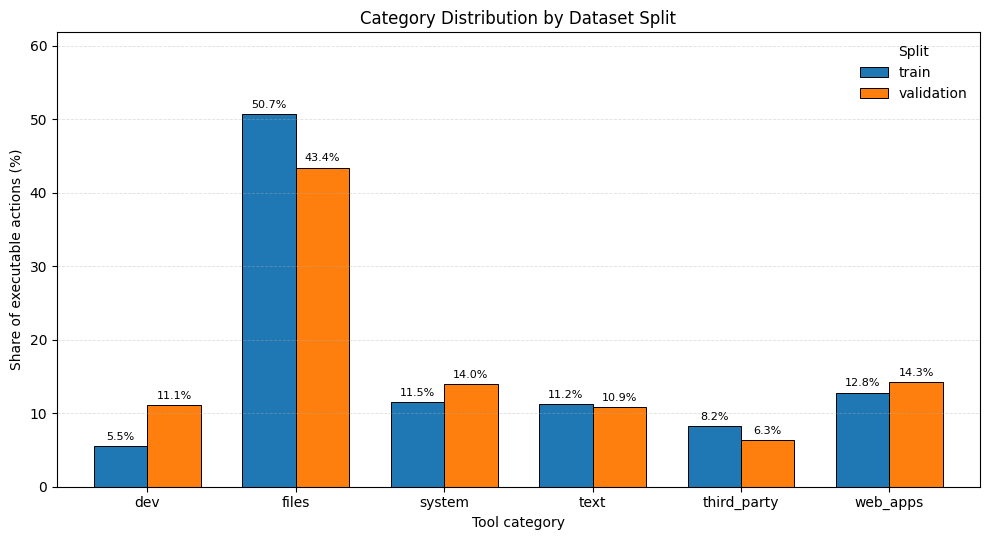

In [23]:
category_plot = (
    category_distribution
    .pivot(
        index="category",
        columns="dataset",
        values="Share (%)",
    )
    .fillna(0)
)

ax = category_plot.plot(
    kind="bar",
    figsize=(10, 5.5),
    width=0.72,
    edgecolor="black",
    linewidth=0.7,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8,
    )

ax.set_xlabel("Tool category")
ax.set_ylabel("Share of executable actions (%)")
ax.set_title("Category Distribution by Dataset Split")
ax.set_ylim(
    0,
    category_plot.to_numpy().max() * 1.22,
)
ax.legend(
    title="Split",
    frameon=False,
)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Figure 3 — Category distribution.** File operations are expected to dominate
because AXION is primarily a local desktop assistant.

Differences between training and validation distributions should be interpreted
carefully: a category that is proportionally overrepresented in validation can
have a larger influence on validation metrics than on actual training updates.

## Tool Coverage

Tool coverage verifies that every tool registered by AXION appears in both the
training and validation splits.

Coverage alone is not sufficient: strongly underrepresented tools may still be
learned less reliably.

In [24]:
tool_coverage = (
    actions_df
    .groupby(["tool", "dataset"])
    .size()
    .unstack(fill_value=0)
    .reindex(sorted(ALL_TOOLS), fill_value=0)
)

for required_column in ("train", "validation"):
    if required_column not in tool_coverage.columns:
        tool_coverage[required_column] = 0

tool_coverage["Total"] = (
    tool_coverage["train"]
    + tool_coverage["validation"]
)

tool_coverage = tool_coverage[
    ["train", "validation", "Total"]
]

display(
    tool_coverage
    .sort_values("Total", ascending=False)
    .style
    .format("{:,.0f}")
)

dataset,train,validation,Total
tool,,,
show_notification,233,11,244
create_folder,206,6,212
open_file,163,6,169
copy_to_clipboard,154,11,165
open_app,151,11,162
reveal_file,131,16,147
create_text_file,128,16,144
organize_folder,133,6,139
create_reminder,127,11,138


In [25]:
missing_tools = tool_coverage[
    (tool_coverage["train"] == 0)
    | (tool_coverage["validation"] == 0)
]

least_covered_tools = (
    tool_coverage
    .sort_values("Total")
    .head(10)
)

print(f"Registered tools: {len(ALL_TOOLS)}")
print(
    "Tools observed in the corpus: "
    f"{(tool_coverage['Total'] > 0).sum()}"
)
print(
    "Tools missing from at least one split: "
    f"{len(missing_tools)}"
)

if missing_tools.empty:
    print(
        "Every registered tool appears in both "
        "training and validation."
    )
else:
    display(missing_tools)

display(
    least_covered_tools.style
    .set_caption("Ten least represented tools")
    .format("{:,.0f}")
)

Registered tools: 37
Tools observed in the corpus: 37
Tools missing from at least one split: 0
Every registered tool appears in both training and validation.


dataset,train,validation,Total
tool,,,
list_processes,18,6,24
rename_file,18,6,24
toggle_dark_mode,14,10,24
get_file_info,20,6,26
get_battery_status,20,6,26
set_volume,16,11,27
move_file,23,6,29
delete_file,23,6,29
quit_app,24,6,30


In [26]:
TOOL_COVERAGE_RESULTS = {
    # Transcribed from the raw outputs produced by the dataset audit cells.
    "registered_tools": 37,
    "observed_tools": 37,
    "tools_missing_from_train": 0,
    "tools_missing_from_validation": 0,
}

In [27]:
assert (
    len(ALL_TOOLS)
    == TOOL_COVERAGE_RESULTS["registered_tools"]
)

assert (
    int((tool_coverage["Total"] > 0).sum())
    == TOOL_COVERAGE_RESULTS["observed_tools"]
)

assert (
    int((tool_coverage["train"] == 0).sum())
    == TOOL_COVERAGE_RESULTS["tools_missing_from_train"]
)

assert (
    int((tool_coverage["validation"] == 0).sum())
    == TOOL_COVERAGE_RESULTS["tools_missing_from_validation"]
)

print(
    "Tool coverage matches the canonical audited output."
)


Tool coverage matches the canonical audited output.


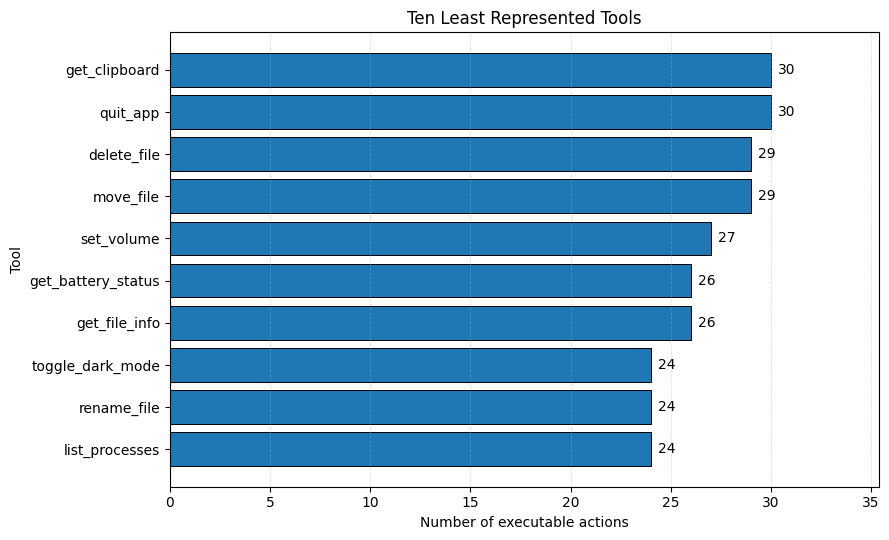

In [28]:
least_covered_plot = (
    least_covered_tools
    .sort_values("Total", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    least_covered_plot.index,
    least_covered_plot["Total"],
    edgecolor="black",
    linewidth=0.7,
)

for bar in bars:
    value = bar.get_width()

    ax.annotate(
        f"{value:.0f}",
        (
            value,
            bar.get_y() + bar.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
    )

ax.set_xlabel("Number of executable actions")
ax.set_ylabel("Tool")
ax.set_title("Ten Least Represented Tools")
ax.set_xlim(
    0,
    least_covered_plot["Total"].max() * 1.18,
)
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

## Sequence-Length Statistics

Prompt and completion length affect training cost, batching efficiency and the
amount of context required to represent each routing behavior.

Character and whitespace-separated word counts are used here as lightweight
descriptive measures. They are not exact tokenizer counts.

In [29]:
examples_df["prompt_chars"] = (
    examples_df["prompt"].str.len()
)

examples_df["prompt_words"] = (
    examples_df["prompt"]
    .str.split()
    .str.len()
)

examples_df["completion_chars"] = (
    examples_df["completion"].str.len()
)

examples_df["completion_words"] = (
    examples_df["completion"]
    .str.split()
    .str.len()
)

length_summary = (
    examples_df[
        [
            "prompt_chars",
            "prompt_words",
            "completion_chars",
            "completion_words",
        ]
    ]
    .describe()
    .round(2)
)

display(length_summary)

,prompt_chars,prompt_words,completion_chars,completion_words
count,2594.00,2594.00,2594.00,2594.00
mean,74.66,10.07,138.76,1.76
std,85.92,12.02,100.38,1.44
min,7.00,2.00,31.00,1.00
25%,31.00,4.00,89.00,1.00
50%,44.50,5.00,116.00,1.00
75%,66.00,9.00,143.00,2.00
max,474.00,61.00,587.00,11.00


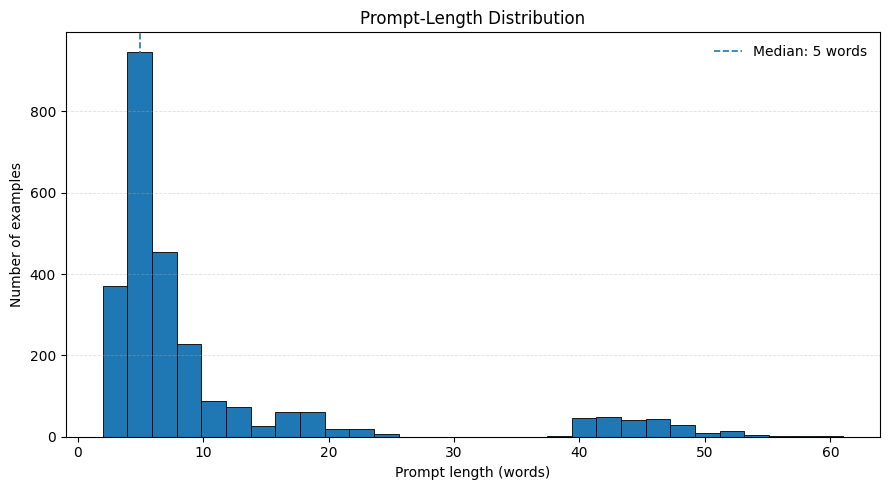

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    examples_df["prompt_words"],
    bins=30,
    edgecolor="black",
    linewidth=0.6,
)

ax.axvline(
    examples_df["prompt_words"].median(),
    linestyle="--",
    linewidth=1.2,
    label=(
        "Median: "
        f"{examples_df['prompt_words'].median():.0f} words"
    ),
)

ax.set_xlabel("Prompt length (words)")
ax.set_ylabel("Number of examples")
ax.set_title("Prompt-Length Distribution")
ax.legend(frameon=False)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

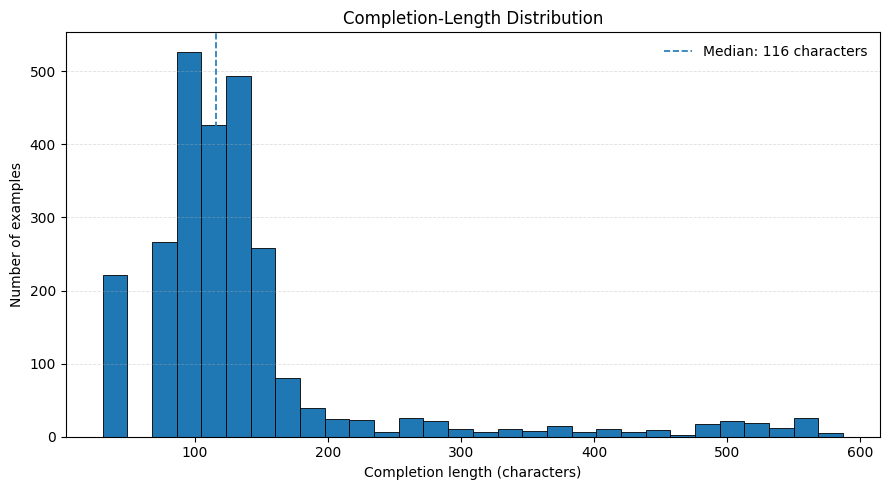

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    examples_df["completion_chars"],
    bins=30,
    edgecolor="black",
    linewidth=0.6,
)

ax.axvline(
    examples_df["completion_chars"].median(),
    linestyle="--",
    linewidth=1.2,
    label=(
        "Median: "
        f"{examples_df['completion_chars'].median():.0f} characters"
    ),
)

ax.set_xlabel("Completion length (characters)")
ax.set_ylabel("Number of examples")
ax.set_title("Completion-Length Distribution")
ax.legend(frameon=False)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

## Plan Analysis

Only `plan` examples are included in this section. Direct `tool_call` examples
contain one action, while `final` examples contain no executable action.

In [32]:
plan_examples_df = examples_df[
    examples_df["response_type"] == "plan"
].copy()

plan_length_distribution = (
    plan_examples_df
    .groupby(["dataset", "step_count"])
    .size()
    .rename("Plans")
    .reset_index()
)

display(
    plan_length_distribution.style
    .hide(axis="index")
)

dataset,step_count,Plans
train,2,66
train,3,43
train,4,63
train,5,104
validation,2,50
validation,3,10


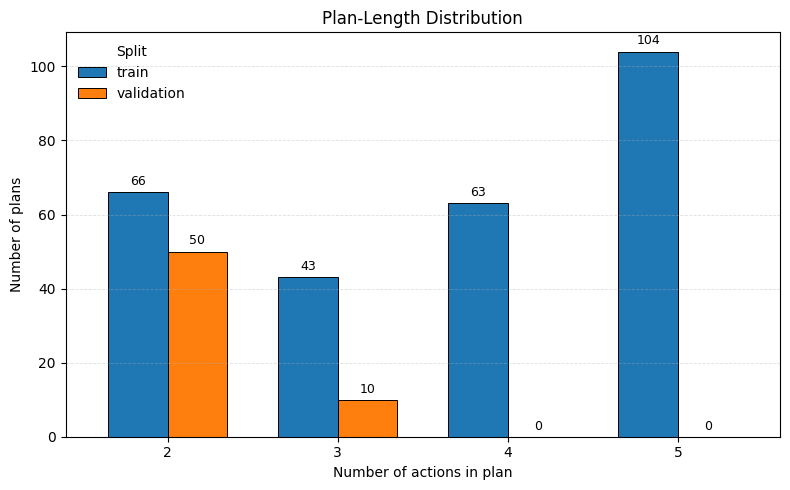

In [33]:
plan_plot = (
    plan_length_distribution
    .pivot(
        index="step_count",
        columns="dataset",
        values="Plans",
    )
    .fillna(0)
)

ax = plan_plot.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.7,
    edgecolor="black",
    linewidth=0.7,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9,
    )

ax.set_xlabel("Number of actions in plan")
ax.set_ylabel("Number of plans")
ax.set_title("Plan-Length Distribution")
ax.legend(
    title="Split",
    frameon=False,
)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
invalid_plan_lengths = plan_examples_df[
    ~plan_examples_df["step_count"].between(2, 5)
][
    [
        "dataset",
        "index",
        "prompt",
        "step_count",
        "tools",
    ]
]

print(
    "Plans outside the allowed 2–5 step range: "
    f"{len(invalid_plan_lengths)}"
)

if not invalid_plan_lengths.empty:
    display(invalid_plan_lengths)

Plans outside the allowed 2–5 step range: 0


In [35]:
assert (
    len(invalid_plan_lengths)
    == DATASET_AUDIT["invalid_plan_lengths"]
)

print("All plans respect the two-to-five-step protocol.")

All plans respect the two-to-five-step protocol.


## Parameter Distribution

Parameter counts indicate how much argument extraction each example requires.
An action with the correct tool but incorrect parameters still fails strict
routing evaluation.

In [36]:
parameter_summary = (
    examples_df["parameter_count"]
    .describe()
    .to_frame("Value")
    .round(2)
)

parameter_distribution = (
    examples_df["parameter_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Parameter count")
    .rename("Examples")
    .reset_index()
)

display(parameter_summary)
display(parameter_distribution)

,Value
count,2594.00
mean,1.72
std,1.56
min,0.00
25%,1.00
50%,1.00
75%,2.00
max,9.00


,Parameter count,Examples
0,0,388
1,1,925
2,2,915
3,3,178
4,4,29
5,5,33
6,6,34
7,7,44
8,8,40
9,9,8


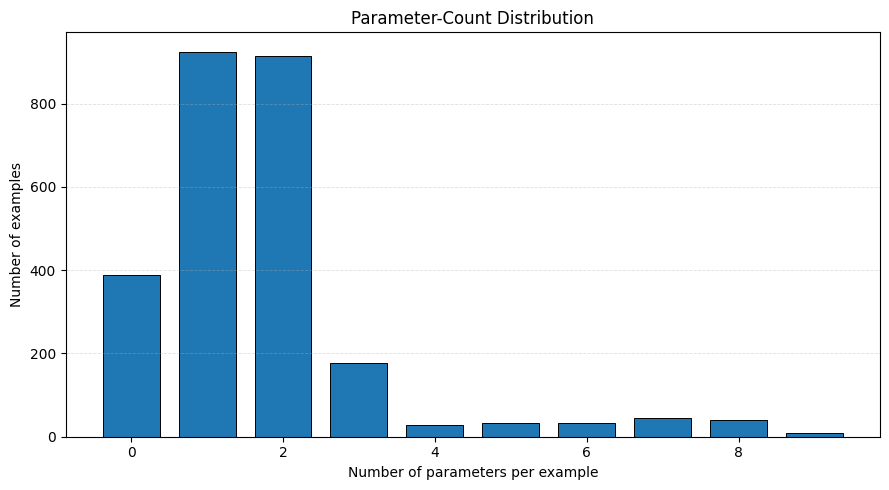

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    parameter_distribution["Parameter count"],
    parameter_distribution["Examples"],
    width=0.75,
    edgecolor="black",
    linewidth=0.7,
)

ax.set_xlabel("Number of parameters per example")
ax.set_ylabel("Number of examples")
ax.set_title("Parameter-Count Distribution")
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

## Dataset Integrity and Leakage Checks

Exact duplicate and overlap checks help detect repeated examples and direct
contamination between training, validation and benchmark data.

These checks detect exact or normalized-string matches. They do not detect all
semantic paraphrases.

In [38]:
def normalize_prompt(text: str) -> str:
    """Normalize a prompt for exact leakage comparisons."""
    normalized = text.strip().lower()
    normalized = re.sub(r"\s+", " ", normalized)
    return normalized


examples_df["normalized_prompt"] = (
    examples_df["prompt"]
    .map(normalize_prompt)
)

In [39]:
duplicate_prompt_rows = examples_df[
    examples_df.duplicated(
        subset=["dataset", "normalized_prompt"],
        keep=False,
    )
].sort_values(
    ["dataset", "normalized_prompt"]
)

train_prompts = set(
    examples_df.loc[
        examples_df["dataset"] == "train",
        "normalized_prompt",
    ]
)

validation_prompts = set(
    examples_df.loc[
        examples_df["dataset"] == "validation",
        "normalized_prompt",
    ]
)

train_validation_overlap = (
    train_prompts
    & validation_prompts
)

duplicate_prompt_group_count = (
    duplicate_prompt_rows["normalized_prompt"].nunique()
)

duplicate_completion_rows = int(
    examples_df["completion"].duplicated().sum()
)

conflicting_prompts = (
    examples_df
    .groupby(["dataset", "normalized_prompt"])["completion"]
    .nunique()
    .reset_index(name="unique_completions")
)

conflicting_prompts = conflicting_prompts[
    conflicting_prompts["unique_completions"] > 1
]

print(
    "Duplicate normalized prompts within splits:",
    duplicate_prompt_group_count,
)

print(
    "Prompt overlap between train and validation:",
    len(train_validation_overlap),
)

print(
    "Duplicate completion strings:",
    duplicate_completion_rows,
)

print(
    "Normalized prompts with conflicting completions:",
    len(conflicting_prompts),
)

assert (
    duplicate_prompt_group_count
    == DATASET_AUDIT["normalized_duplicate_prompt_groups"]
)

assert (
    duplicate_completion_rows
    == DATASET_AUDIT["duplicate_completion_rows"]
)

assert (
    len(conflicting_prompts)
    == DATASET_AUDIT["conflicting_normalized_prompts"]
)

assert (
    len(train_validation_overlap)
    == DATASET_AUDIT["train_validation_overlap"]
)

print(
    "Duplicate and train/validation integrity results "
    "match the canonical audited output."
)


Duplicate normalized prompts within splits: 2
Prompt overlap between train and validation: 0
Duplicate completion strings: 1122
Normalized prompts with conflicting completions: 0
Duplicate and train/validation integrity results match the canonical audited output.


### Duplicate Interpretation

A small number of normalized duplicate prompts may remain within the same
split. These rows are not automatically invalid if they map to the same
completion.

The stronger integrity condition is that identical normalized prompts must not
produce conflicting completions. The audit verifies this condition explicitly.
Repeated completion strings are also expected because several natural-language
paraphrases can map to the same deterministic tool call.

In [40]:
def extract_benchmark_prompt(
    record: dict[str, Any],
) -> str | None:
    """Extract a prompt from the benchmark's actual schema."""
    for key in ("prompt", "input", "query", "user"):
        value = record.get(key)

        if isinstance(value, str) and value.strip():
            return value

    return None


benchmark_prompt_rows = []

for index, record in enumerate(datasets["benchmark"]):
    prompt = extract_benchmark_prompt(record)

    if prompt is not None:
        benchmark_prompt_rows.append({
            "index": index,
            "prompt": prompt,
            "normalized_prompt": normalize_prompt(prompt),
        })

benchmark_prompts_df = pd.DataFrame(
    benchmark_prompt_rows
)

print(
    "Benchmark prompts extracted: "
    f"{len(benchmark_prompts_df):,} / "
    f"{len(datasets['benchmark']):,}"
)

Benchmark prompts extracted: 320 / 320


In [41]:
if datasets["benchmark"]:
    print(
        "Benchmark top-level keys:",
        sorted(datasets["benchmark"][0].keys()),
    )

assert len(benchmark_prompts_df) == len(datasets["benchmark"]), (
    "Not every benchmark prompt could be extracted. "
    "Update extract_benchmark_prompt() for the real schema."
)


Benchmark top-level keys: ['completion', 'prompt']


In [42]:
benchmark_prompt_set = set(
    benchmark_prompts_df["normalized_prompt"]
)

train_benchmark_overlap = (
    train_prompts
    & benchmark_prompt_set
)

validation_benchmark_overlap = (
    validation_prompts
    & benchmark_prompt_set
)

print(
    "Exact normalized overlap — train / benchmark:",
    len(train_benchmark_overlap),
)

print(
    "Exact normalized overlap — validation / benchmark:",
    len(validation_benchmark_overlap),
)

assert (
    len(train_benchmark_overlap)
    == DATASET_AUDIT["train_benchmark_overlap"]
)

assert (
    len(validation_benchmark_overlap)
    == DATASET_AUDIT["validation_benchmark_overlap"]
)

print("The benchmark is exactly separated from both supervised splits.")

Exact normalized overlap — train / benchmark: 0
Exact normalized overlap — validation / benchmark: 0
The benchmark is exactly separated from both supervised splits.


### Leakage Interpretation

The cleaned corpus contains no exact normalized prompt overlap between:

- training and validation;
- training and benchmark;
- validation and benchmark.

This separation was established before the `finetuning-v6` training run.

The result removes the direct prompt contamination identified in the previous
dataset version. It does not prove the absence of semantic or template-level
similarity, which remains a limitation of exact-string analysis.

In [43]:
benchmark_overlap_rate = (
    len(train_benchmark_overlap)
    / len(benchmark_prompt_set)
    * 100
    if benchmark_prompt_set
    else 0.0
)

dataset_is_structurally_valid = (
    len(validation_errors_df) == 0
    and len(invalid_plan_lengths) == 0
)

benchmark_is_independent = (
    len(train_benchmark_overlap) == 0
    and len(validation_benchmark_overlap) == 0
)

AUDIT_STATUS = {
    # Transcribed from the raw outputs produced by the dataset audit cells.
    "dataset_structurally_valid": dataset_is_structurally_valid,
    "benchmark_independent": benchmark_is_independent,
    "benchmark_exposure_rate_percent": benchmark_overlap_rate,
}

display(
    pd.DataFrame({
        "Check": [
            "Dataset structurally valid",
            "Benchmark independent",
            "Benchmark exposure rate",
        ],
        "Result": [
            AUDIT_STATUS["dataset_structurally_valid"],
            AUDIT_STATUS["benchmark_independent"],
            (
                f'{AUDIT_STATUS["benchmark_exposure_rate_percent"]:.1f}%'
            ),
        ],
    }).style.hide(axis="index")
)

assert dataset_is_structurally_valid
assert benchmark_is_independent

Check,Result
Dataset structurally valid,True
Benchmark independent,True
Benchmark exposure rate,0.0%


In [44]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Dataset version",
        "Training examples",
        "Validation examples",
        "Supervised examples",
        "Benchmark examples",
        "Registered tools",
        "Observed tools",
        "Tool coverage",
        "Schema errors",
        "Invalid plan lengths",
        "Normalized duplicate prompt groups",
        "Conflicting normalized prompts",
        "Duplicate completion rows",
        "Train/validation prompt overlap",
        "Train/benchmark prompt overlap",
        "Validation/benchmark prompt overlap",
        "Benchmark exposure rate",
        "Average prompt length",
        "Average completion length",
        "Average actions per example",
        "Average parameters per example",
    ],
    "Value": [
        DATASET_AUDIT["version"],
        DATASET_AUDIT["training_examples"],
        DATASET_AUDIT["validation_examples"],
        DATASET_AUDIT["supervised_examples"],
        DATASET_AUDIT["benchmark_examples"],
        DATASET_AUDIT["registered_tools"],
        int((tool_coverage["Total"] > 0).sum()),
        f"{(tool_coverage['Total'] > 0).mean() * 100:.1f}%",
        DATASET_AUDIT["schema_errors"],
        DATASET_AUDIT["invalid_plan_lengths"],
        DATASET_AUDIT["normalized_duplicate_prompt_groups"],
        DATASET_AUDIT["conflicting_normalized_prompts"],
        DATASET_AUDIT["duplicate_completion_rows"],
        DATASET_AUDIT["train_validation_overlap"],
        DATASET_AUDIT["train_benchmark_overlap"],
        DATASET_AUDIT["validation_benchmark_overlap"],
        (
            f'{DATASET_AUDIT["benchmark_exposure_rate_percent"]:.1f}%'
        ),
        f"{examples_df['prompt_words'].mean():.1f} words",
        (
            f"{examples_df['completion_chars'].mean():.1f} "
            "characters"
        ),
        f"{examples_df['step_count'].mean():.2f}",
        f"{examples_df['parameter_count'].mean():.2f}",
    ],
})

display(
    dataset_summary.style
    .hide(axis="index")
)


Metric,Value
Dataset version,finetuning-v6-clean
Training examples,2294
Validation examples,300
Supervised examples,2594
Benchmark examples,320
Registered tools,37
Observed tools,37
Tool coverage,100.0%
Schema errors,0
Invalid plan lengths,0


## Threats to Validity

This audit has several limitations:

1. Exact overlap checks do not detect semantically equivalent paraphrases.
2. Word and character counts are not equivalent to model-token counts.
3. Tool coverage does not guarantee balanced linguistic diversity.
4. Validation may contain a different response-type distribution from training.
5. Closely related templates may remain present across splits without being
   exact string matches.
6. Dataset quality is evaluated structurally, not through exhaustive human
   annotation of every prompt/completion pair.

## Conclusion

The cleaned AXION corpus used for `finetuning-v6` contains:

- 2,294 training examples;
- 300 validation examples;
- 2,594 supervised examples in total;
- a separate 320-prompt benchmark.

The final audit confirms:

- zero schema errors;
- zero plans outside the declared two-to-five-step protocol;
- complete coverage of the 37 registered tools;
- zero exact normalized overlap between training and validation;
- zero exact normalized overlap between training and benchmark;
- zero exact normalized overlap between validation and benchmark.

The dataset is therefore structurally ready for the controlled LoRA experiment
documented in Notebook 04.

All headline values in this notebook are transcribed from the raw outputs
produced by the dataset audit cells and stored in explicit Python dictionaries.
The live audit code remains available to verify that the versioned JSONL files
still reproduce those values.